# Running Ensemble Inference

Simple ensemble inference workflow.

This example will demonstrate how to run a simple inference workflow to generate a
ensemble forecast using one of the built in models of Earth-2 Inference
Studio.

In this example you will learn:

- How to instantiate a built in prognostic model
- Creating a data source and IO object
- Select a perturbation method
- Running a simple built in workflow for ensembling
- Post-processing results

## Set Up
All workflows inside Earth2Studio require constructed components to be
handed to them. In this example, we will use the built in ensemble workflow
[`earth2studio.run.ensemble`][earth2studio.run.ensemble].

```python
# SPDX-FileCopyrightText: Copyright (c) 2024-2026 NVIDIA CORPORATION & AFFILIATES.
# SPDX-FileCopyrightText: All rights reserved.
# SPDX-License-Identifier: Apache-2.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from collections import OrderedDict
from datetime import datetime
from math import ceil

import numpy as np
import torch
from loguru import logger
from tqdm import tqdm

from earth2studio.data import DataSource, ForecastSource, fetch_data
from earth2studio.io import IOBackend
from earth2studio.models.dx import DiagnosticModel
from earth2studio.models.px import PrognosticModel
from earth2studio.perturbation import Perturbation
from earth2studio.utils.checkpoint import (
    Checkpoint,
    CheckpointSession,
    NullCheckpoint,
)
from earth2studio.utils.coords import CoordSystem, map_coords, split_coords
from earth2studio.utils.time import to_time_array

logger.remove()
logger.add(lambda msg: tqdm.write(msg, end=""), colorize=True)


def deterministic(
    time: list[str] | list[datetime] | list[np.datetime64],
    nsteps: int,
    prognostic: PrognosticModel,
    data: DataSource,
    io: IOBackend,
    output_coords: CoordSystem = OrderedDict({}),
    device: torch.device | None = None,
    verbose: bool = True,
    checkpoint: Checkpoint | CheckpointSession | NullCheckpoint = NullCheckpoint(),
) -> IOBackend:
    """Built in deterministic workflow.
    This workflow creates a determinstic inference pipeline to produce a forecast
    prediction using a prognostic model.

    Parameters
    ----------
    time : list[str] | list[datetime] | list[np.datetime64]
        List of string, datetimes or np.datetime64
    nsteps : int
        Number of forecast steps
    prognostic : PrognosticModel
        Prognostic model
    data : DataSource
        Data source
    io : IOBackend
        IO object
    output_coords: CoordSystem, optional
        IO output coordinate system override, by default OrderedDict({})
    device : torch.device, optional
        Device to run inference on, by default None
    verbose : bool, optional
        Print inference progress, by default True
    checkpoint : Checkpoint, optional
        Checkpoint manager or checkpoint session used to record and resume workflow
        progress, by default no checkpoint

    Returns
    -------
    IOBackend
        Output IO object
    """
    logger.info("Running simple workflow!")
    # Load model onto the device
    device = (
        device
        if device is not None
        else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )
    logger.info(f"Inference device: {device}")
    prognostic = prognostic.to(device)
    prognostic_ic = prognostic.input_coords()
    time = to_time_array(time)

    # Set up IO backend
    total_coords = prognostic.output_coords(prognostic.input_coords()).copy()
    for key, value in prognostic.output_coords(
        prognostic.input_coords()
    ).items():  # Scrub batch dims
        if value.shape == (0,):
            del total_coords[key]
    total_coords["time"] = time
    total_coords["lead_time"] = np.asarray(
        [
            prognostic.output_coords(prognostic.input_coords())["lead_time"] * i
            for i in range(nsteps + 1)
        ]
    ).flatten()
    total_coords.move_to_end("lead_time", last=False)
    total_coords.move_to_end("time", last=False)

    for key, value in total_coords.items():
        total_coords[key] = output_coords.get(key, value)
    var_names = total_coords.pop("variable")
    io.add_array(total_coords, var_names)

    with checkpoint as ckpt:
        restart_step = None
        if ckpt.exists and ckpt.write_count > 0:
            if ckpt.catalog.level < 2:
                logger.warning(
                    "deterministic received checkpoint level "
                    f"{ckpt.catalog.level}; component state may not be "
                    "complete enough to resume a rollout. Re-running from "
                    "lead time zero."
                )
            else:
                restart_step = ckpt.write_count - 1
                if restart_step >= nsteps:
                    logger.success("\nInference complete")
                    return io

        # --8<-- [start:fetch-data]
        # Fetch data from data source and load onto device
        if hasattr(prognostic, "interp_method"):
            interp_to = prognostic_ic
            interp_method = prognostic.interp_method
        else:
            interp_to = None
            interp_method = "nearest"

        x, coords = fetch_data(
            source=data,
            time=time,
            variable=prognostic_ic["variable"],
            lead_time=prognostic_ic["lead_time"],
            device=device,
            interp_to=interp_to,
            interp_method=interp_method,
        )

        logger.success(f"Fetched data from {data.__class__.__name__}")
        # --8<-- [end:fetch-data]

        # Map lat and lon if needed
        x, coords = map_coords(x, coords, prognostic.input_coords())
        # Create prognostic iterator
        model = prognostic.create_iterator(x, coords)

        logger.info("Inference starting!")
        initial_progress = 0 if restart_step is None else restart_step + 1
        with tqdm(
            total=nsteps + 1,
            initial=initial_progress,
            desc="Running inference",
            position=1,
            disable=(not verbose),
        ) as pbar:
            for local_step, (x, coords) in enumerate(model):
                step = (
                    local_step
                    if restart_step is None
                    else restart_step + local_step + 1
                )

                current_lead_time = coords["lead_time"][-1]
                # Subselect domain/variables as indicated in output_coords
                x, coords = map_coords(x, coords, output_coords)
                io.write(*split_coords(x, coords))
                ckpt.write(lead_time=current_lead_time)
                pbar.update(1)
                if step == nsteps:
                    break

        ckpt.flush()

    logger.success("\nInference complete")
    return io


def diagnostic(
    time: list[str] | list[datetime] | list[np.datetime64],
    nsteps: int,
    prognostic: PrognosticModel,
    diagnostic: DiagnosticModel,
    data: DataSource | ForecastSource,
    io: IOBackend,
    output_coords: CoordSystem = OrderedDict({}),
    device: torch.device | None = None,
    verbose: bool = True,
    checkpoint: Checkpoint | CheckpointSession | NullCheckpoint = NullCheckpoint(),
) -> IOBackend:
    """Built in diagnostic workflow.
    This workflow creates a determinstic inference pipeline that couples a prognostic
    model with a diagnostic model.

    Parameters
    ----------
    time : list[str] | list[datetime] | list[np.datetime64]
        List of string, datetimes or np.datetime64
    nsteps : int
        Number of forecast steps
    prognostic : PrognosticModel
        Prognostic model
    diagnostic: DiagnosticModel
        Diagnostic model, must be on same coordinate axis as prognostic
    data : DataSource | ForecastSource
        Data source
    io : IOBackend
        IO object
    output_coords: CoordSystem, optional
        IO output coordinate system override, by default OrderedDict({})
    device : torch.device, optional
        Device to run inference on, by default None
    verbose : bool, optional
        Print inference progress, by default True
    checkpoint : Checkpoint, optional
        Checkpoint manager or checkpoint session used to record and resume workflow
        progress, by default no checkpoint

    Returns
    -------
    IOBackend
        Output IO object
    """
    logger.info("Running diagnostic workflow!")
    device = (
        device
        if device is not None
        else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )
    logger.info(f"Inference device: {device}")
    prognostic = prognostic.to(device)
    diagnostic = diagnostic.to(device)

    prognostic_ic = prognostic.input_coords()
    diagnostic_ic = diagnostic.input_coords()
    time = to_time_array(time)

    total_coords = prognostic.output_coords(prognostic.input_coords())
    for key, value in prognostic.output_coords(
        prognostic.input_coords()
    ).items():  # Scrub batch dims
        if key in diagnostic.output_coords(diagnostic_ic):
            total_coords[key] = diagnostic.output_coords(diagnostic_ic)[key]
        if value.shape == (0,):
            del total_coords[key]
    total_coords["time"] = time
    total_coords["lead_time"] = np.asarray(
        [
            prognostic.output_coords(prognostic.input_coords())["lead_time"] * i
            for i in range(nsteps + 1)
        ]
    ).flatten()
    total_coords.move_to_end("lead_time", last=False)
    total_coords.move_to_end("time", last=False)

    for key, value in total_coords.items():
        total_coords[key] = output_coords.get(key, value)
    var_names = total_coords.pop("variable")
    io.add_array(total_coords, var_names)

    with checkpoint as ckpt:
        restart_step = None
        if ckpt.exists and ckpt.write_count > 0:
            if ckpt.catalog.level < 2:
                logger.warning(
                    "diagnostic received checkpoint level "
                    f"{ckpt.catalog.level}; component state may not be "
                    "complete enough to resume a rollout. Re-running from "
                    "lead time zero."
                )
            else:
                restart_step = ckpt.write_count - 1
                if restart_step >= nsteps:
                    logger.success("\nInference complete")
                    return io

        if hasattr(prognostic, "interp_method"):
            interp_to = prognostic_ic
            interp_method = prognostic.interp_method
        else:
            interp_to = None
            interp_method = "nearest"

        x, coords = fetch_data(
            source=data,
            time=time,
            variable=prognostic_ic["variable"],
            lead_time=prognostic_ic["lead_time"],
            device=device,
            interp_to=interp_to,
            interp_method=interp_method,
        )
        logger.success(f"Fetched data from {data.__class__.__name__}")

        x, coords = map_coords(x, coords, prognostic_ic)
        model = prognostic.create_iterator(x, coords)

        logger.info("Inference starting!")
        initial_progress = 0 if restart_step is None else restart_step + 1
        with tqdm(
            total=nsteps + 1,
            initial=initial_progress,
            desc="Running inference",
            position=1,
            disable=(not verbose),
        ) as pbar:
            for local_step, (x, coords) in enumerate(model):
                step = (
                    local_step
                    if restart_step is None
                    else restart_step + local_step + 1
                )

                current_lead_time = coords["lead_time"][-1]
                x, coords = map_coords(x, coords, diagnostic_ic)
                x, coords = diagnostic(x, coords)
                x, coords = map_coords(x, coords, output_coords)
                io.write(*split_coords(x, coords))
                ckpt.write(lead_time=current_lead_time)
                pbar.update(1)
                if step == nsteps:
                    break

        ckpt.flush()

    logger.success("\nInference complete")
    return io


def ensemble(
    time: list[str] | list[datetime] | list[np.datetime64],
    nsteps: int,
    nensemble: int,
    prognostic: PrognosticModel,
    data: DataSource,
    io: IOBackend,
    perturbation: Perturbation,
    batch_size: int | None = None,
    output_coords: CoordSystem = OrderedDict({}),
    device: torch.device | None = None,
    verbose: bool = True,
    checkpoint: Checkpoint | CheckpointSession | NullCheckpoint = NullCheckpoint(),
) -> IOBackend:
    """Built in ensemble workflow.

    Parameters
    ----------
    time : list[str] | list[datetime] | list[np.datetime64]
        List of string, datetimes or np.datetime64
    nsteps : int
        Number of forecast steps
    nensemble : int
        Number of ensemble members to run inference for.
    prognostic : PrognosticModel
        Prognostic models
    data : DataSource
        Data source
    io : IOBackend
        IO object
    perturbation : Perturbation
        Method to perturb the initial condition to create an ensemble.
    batch_size: int, optional
        Number of ensemble members to run in a single batch,
        by default None.
    output_coords: CoordSystem, optional
        IO output coordinate system override, by default OrderedDict({})
    device : torch.device, optional
        Device to run inference on, by default None
    verbose : bool, optional
        Print inference progress, by default True
    checkpoint : Checkpoint, optional
        Checkpoint manager or checkpoint session used to record and resume workflow
        progress, by default no checkpoint

    Returns
    -------
    IOBackend
        Output IO object
    """
    logger.info("Running ensemble inference!")

    device = (
        device
        if device is not None
        else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    )
    logger.info(f"Inference device: {device}")
    prognostic = prognostic.to(device)

    prognostic_ic = prognostic.input_coords()
    time = to_time_array(time)
    if hasattr(prognostic, "interp_method"):
        interp_to = prognostic_ic
        interp_method = prognostic.interp_method
    else:
        interp_to = None
        interp_method = "nearest"

    x0, coords0 = fetch_data(
        source=data,
        time=time,
        variable=prognostic_ic["variable"],
        lead_time=prognostic_ic["lead_time"],
        device=device,
        interp_to=interp_to,
        interp_method=interp_method,
    )
    logger.success(f"Fetched data from {data.__class__.__name__}")

    total_coords = prognostic.output_coords(prognostic.input_coords()).copy()
    if "batch" in total_coords:
        del total_coords["batch"]
    total_coords["time"] = time
    total_coords["lead_time"] = np.asarray(
        [
            prognostic.output_coords(prognostic.input_coords())["lead_time"] * i
            for i in range(nsteps + 1)
        ]
    ).flatten()
    total_coords.move_to_end("lead_time", last=False)
    total_coords.move_to_end("time", last=False)
    total_coords = {"ensemble": np.arange(nensemble)} | total_coords

    for key, value in total_coords.items():
        total_coords[key] = output_coords.get(key, value)
    variables_to_save = total_coords.pop("variable")
    io.add_array(total_coords, variables_to_save)

    if batch_size is None:
        batch_size = nensemble
    batch_size = min(nensemble, batch_size)
    with checkpoint as ckpt:
        completed_ensembles = []
        if ckpt.exists and not isinstance(ckpt, NullCheckpoint):
            completed_ensembles = [
                int(value) for value in ckpt.metadata.get("completed_ensembles", [])
            ]

        completed = set(completed_ensembles)
        start_batch_id = next(
            (index for index in range(nensemble) if index not in completed),
            nensemble,
        )
        number_of_batches = ceil((nensemble - start_batch_id) / batch_size)
        restart_first_batch = (
            ckpt.exists
            and ckpt.write_count > 0
            and start_batch_id < nensemble
            and ckpt.lead_time != total_coords["lead_time"][-1]
        )

        logger.info(f"Starting {nensemble} Member Ensemble Inference with \
            {number_of_batches} number of batches.")
        for batch_index, batch_id in enumerate(
            tqdm(
                range(start_batch_id, nensemble, batch_size),
                total=number_of_batches,
                desc="Total Ensemble Batches",
                position=2,
                disable=(not verbose),
            )
        ):
            mini_batch_size = min(batch_size, nensemble - batch_id)
            ensemble_coords = np.arange(batch_id, batch_id + mini_batch_size)
            ensemble_members = [int(value) for value in ensemble_coords]
            restart_step = None
            if batch_index == 0 and restart_first_batch:
                if ckpt.catalog.level < 2:
                    logger.warning(
                        "ensemble received checkpoint level "
                        f"{ckpt.catalog.level}; component state may not be "
                        "complete enough to resume a rollout. Re-running from "
                        "lead time zero."
                    )
                    ckpt.write_count = 0
                else:
                    restart_step = ckpt.write_count - 1
                    if restart_step >= nsteps:
                        continue
            elif not isinstance(ckpt, NullCheckpoint):
                ckpt.write_count = 0

            x = x0.to(device)
            coords = OrderedDict({"ensemble": ensemble_coords}) | coords0.copy()
            x = x.unsqueeze(0).repeat(mini_batch_size, *([1] * x.ndim))
            x, coords = map_coords(x, coords, prognostic_ic)
            x, coords = perturbation(x, coords)

            model = prognostic.create_iterator(x, coords)
            initial_progress = 0 if restart_step is None else restart_step + 1
            with tqdm(
                total=nsteps + 1,
                initial=initial_progress,
                desc=f"Running batch {batch_id} inference",
                position=1,
                leave=False,
                disable=(not verbose),
            ) as pbar:
                for local_step, (x, coords) in enumerate(model):
                    step = (
                        local_step
                        if restart_step is None
                        else restart_step + local_step + 1
                    )

                    current_lead_time = coords["lead_time"][-1]
                    x, coords = map_coords(x, coords, output_coords)
                    io.write(*split_coords(x, coords))
                    if step == nsteps:
                        completed.update(ensemble_members)
                        completed_ensembles = sorted(completed)
                    ckpt.write(
                        lead_time=current_lead_time,
                        completed_ensembles=completed_ensembles,
                    )
                    pbar.update(1)
                    if step == nsteps:
                        break

            ckpt.flush()

    logger.success("\nInference complete")
    return io
```

We need the following:

- Prognostic Model: Use the built in FourCastNet model [`earth2studio.models.px.FCN`][earth2studio.models.px.FCN].
- Perturbation Method: Use the Spherical Gaussian Method [`earth2studio.perturbation.SphericalGaussian`][earth2studio.perturbation.SphericalGaussian].
- Datasource: Pull data from the GFS data api [`earth2studio.data.GFS`][earth2studio.data.GFS].
- IO Backend: Save the outputs into a Zarr store [`earth2studio.io.ZarrBackend`][earth2studio.io.ZarrBackend].

In [1]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # TODO: make common example prep function

import numpy as np

from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.px import FCN
from earth2studio.perturbation import SphericalGaussian
from earth2studio.run import ensemble
from earth2studio.utils.time import to_time_array

# Load the default model package which downloads the check point from NGC
package = FCN.load_default_package()
model = FCN.load_model(package)

# Instantiate the pertubation method
sg = SphericalGaussian(noise_amplitude=0.15)

# Create the data source
data = GFS()

# Create the IO handler, store in memory
chunks = {"ensemble": 1, "time": 1, "lead_time": 1}
io = ZarrBackend(
    file_name="outputs/03_ensemble_sg.zarr",
    chunks=chunks,
    backend_kwargs={"overwrite": True},
)


## Fetch Data
You can easily fetch raw Xarray data from an initial condition data source with
a simple call. By default, this caches the data locally on your machine, so you
won't have to re-download it if you access it again or use it in an inference
pipeline.

In [2]:
sample = data(
    to_time_array(["2024-01-01"]),
    model.input_coords()["variable"],
)
print(f"Cached GFS input shape: {sample.shape}")


Cached GFS input shape: (1, 26, 721, 1440)


Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 34.57it/s]


## Execute the Workflow
With all components initialized, running the workflow is a single line of Python code.
Workflow will return the provided IO object back to the user, which can be used to
then post process. Some have additional APIs that can be handy for post-processing or
saving to file. Check the API docs for more information.

For the forecast we will predict for 10 steps (for FCN, this is 60 hours) with 8 ensemble
members which will be ran in 2 batches with batch size 4.

In [3]:
nsteps = 10
nensemble = 8
batch_size = 2
io = ensemble(
    ["2024-01-01"],
    nsteps,
    nensemble,
    model,
    data,
    io,
    sg,
    batch_size=batch_size,
    output_coords={"variable": np.array(["t2m", "tcwv"])},
)


2026-08-12 21:04:12.690 | INFO     | earth2studio.run:ensemble:400 - Running ensemble inference!
2026-08-12 21:04:12.691 | INFO     | earth2studio.run:ensemble:407 - Inference device: cuda
2026-08-12 21:04:13.647 | SUCCESS  | earth2studio.run:ensemble:428 - Fetched data from GFS
2026-08-12 21:04:13.668 | INFO     | earth2studio.run:ensemble:472 - Starting 8 Member Ensemble Inference with             4 number of batches.
2026-08-12 21:04:32.169 | SUCCESS  | earth2studio.run:ensemble:542 - 
Inference complete


Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 35.13it/s]


Running batch 0 inference: 100%|██████████| 11/11 [00:03<00:00,  2.93it/s]
                                                                          

Running batch 2 inference: 100%|██████████| 11/11 [00:03<00:00,  2.92it/s]
                                                                          

Running batch 4 inference: 100%|██████████| 11/11 [00:03<00:00,  2.98it/s]
                                                                          

Running batch 6 inference: 100%|██████████| 11/11 [00:03<00:00,  2.96it/s]
                                                                          

Total Ensemble Batches: 100%|██████████| 4/4 [00:18<00:00,  4.63s/it]


## Post Processing
The last step is to post process our results. Cartopy is a great library for plotting
fields on projections of a sphere.

Notice that the Zarr IO function has additional APIs to interact with the stored data.

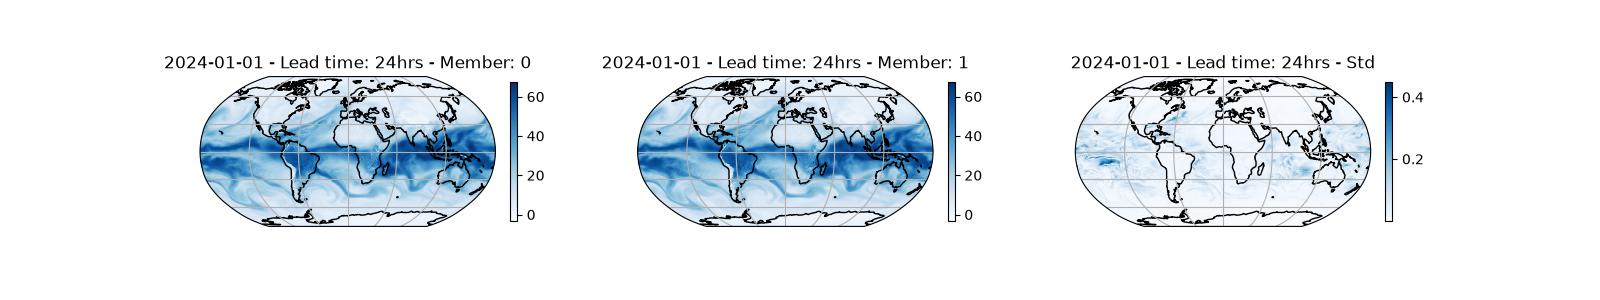

In [4]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

forecast = "2024-01-01"


def plot_(axi, data, title, cmap):
    """Convenience function for plotting pcolormesh."""
    # Plot the field using pcolormesh
    im = axi.pcolormesh(
        io["lon"][:],
        io["lat"][:],
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
    )
    plt.colorbar(im, ax=axi, shrink=0.6, pad=0.04)
    # Set title
    axi.set_title(title)
    # Add coastlines and gridlines
    axi.coastlines()
    axi.gridlines()


for variable, cmap in zip(["tcwv"], ["Blues"]):
    step = 4  # lead time = 24 hrs

    plt.close("all")
    # Create a Robinson projection
    projection = ccrs.Robinson()

    # Create a figure and axes with the specified projection
    fig, (ax1, ax2, ax3) = plt.subplots(
        nrows=1, ncols=3, subplot_kw={"projection": projection}, figsize=(16, 3)
    )

    plot_(
        ax1,
        io[variable][0, 0, step],
        f"{forecast} - Lead time: {6*step}hrs - Member: {0}",
        cmap,
    )
    plot_(
        ax2,
        io[variable][1, 0, step],
        f"{forecast} - Lead time: {6*step}hrs - Member: {1}",
        cmap,
    )
    plot_(
        ax3,
        np.std(io[variable][:, 0, step], axis=0),
        f"{forecast} - Lead time: {6*step}hrs - Std",
        cmap,
    )

    plt.savefig(f"outputs/03_{forecast}_{variable}_{step}_ensemble.jpg")
